# Chapter 17 · Notebook 1: data understanding, cleaning and EDA

Companion to `notes/17_end_to_end_youtube_sentiment.html` (video 04:52:33 onwards, "data collection / preprocessing / EDA").

**Goal of the project:** a Chrome extension that shows the sentiment of a YouTube video's comments.
We need a model that labels a comment as **positive (1)**, **neutral (0)** or **negative (−1)**.
YouTube comments with labels aren't freely available, so the course trains on a labelled **Reddit comments** dataset.

| Step | What we check |
|---|---|
| 1 | load, shape, missing values, duplicates, blank comments |
| 2 | class balance |
| 3 | comment length: words and characters per class |
| 4 | stop words, punctuation, non-English characters |
| 5 | most common bigrams and trigrams |
| 6 | the cleaning function, then before/after examples |
| 7 | word clouds and top words per class |
| 8 | save the cleaned data for notebook 2 |

In [1]:
import os, re, json, warnings
from collections import Counter
import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

for pkg in ("stopwords", "wordnet", "omw-1.4"):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid")
LABELS = {-1: "negative", 0: "neutral", 1: "positive"}
PALETTE = {"negative": "#e34948", "neutral": "#9a9890", "positive": "#1baf7a"}
os.makedirs("../reports", exist_ok=True)
DATA_URL = "https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv"

## 1 · Load and basic checks

In [2]:
df = pd.read_csv(DATA_URL)
print("shape:", df.shape)
print(df.dtypes, "\n")
df.head()

shape: (37249, 2)
clean_comment      str
category         int64
dtype: object 



,clean_comment,category
0,family mormon have never tried explain them they still stare puzzled from time time l...,1
1,buddhism has very much lot compatible with christianity especially considering that si...,1
2,seriously don say thing first all they won get its too complex explain normal people a...,-1
3,what you have learned yours and only yours what you want teach different focus the goa...,0
4,for your own benefit you may want read living buddha living christ thich nhat hanh you...,1


In [3]:
print("missing values:\n", df.isna().sum(), "\n")
print("duplicate rows:", df.duplicated().sum())
print("blank comments (only spaces):", (df["clean_comment"].fillna("").str.strip() == "").sum())

df = df.dropna(subset=["clean_comment"]).drop_duplicates()
df = df[df["clean_comment"].str.strip() != ""].reset_index(drop=True)
print("after cleaning:", df.shape)

missing values:
 clean_comment    100
category           0
dtype: int64 

duplicate rows: 449
blank comments (only spaces): 221
after cleaning: (36793, 2)


## 2 · Class balance: the dataset is imbalanced

           rows  percent
label                   
positive  15771     42.9
neutral   12772     34.7
negative   8250     22.4


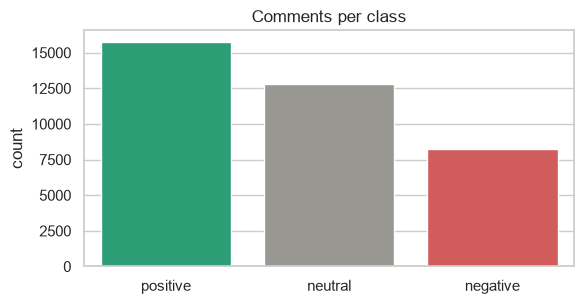

In [4]:
df["label"] = df["category"].map(LABELS)
dist = df["label"].value_counts()
share = (dist / len(df) * 100).round(1)
print(pd.DataFrame({"rows": dist, "percent": share}))

fig, ax = plt.subplots(figsize=(6, 3.2))
sns.countplot(data=df, x="label", order=["positive", "neutral", "negative"], palette=PALETTE, ax=ax)
ax.set_title("Comments per class"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig("../reports/eda_class_balance.png", dpi=110); plt.show()
EDA = {"rows": int(len(df)), "class_percent": share.to_dict()}

Positive comments are the largest class and negative the smallest (about 22%).
A model can score well on accuracy while missing many negative comments, so later we watch **negative-class recall**
and try imbalance fixes (experiment 4).

## 3 · How long are comments?

label             negative  neutral  positive
word_count count    8250.0  12772.0   15771.0
           mean       34.9      9.9      42.9
           std        52.5     13.3      73.7
           min         1.0      1.0       1.0
           25%        10.0      4.0      10.0
           50%        20.0      7.0      21.0
           75%        39.0     12.0      46.0
           max       865.0    518.0    1307.0
char_count count    8250.0  12772.0   15771.0
           mean      215.4     60.7     265.1
           std       335.1     80.0     467.6
           min         3.0      1.0       3.0
           25%        63.0     23.0      62.0
           50%       119.0     40.0     128.0
           75%       241.0     71.0     282.0
           max      5875.0   2074.0    8665.0


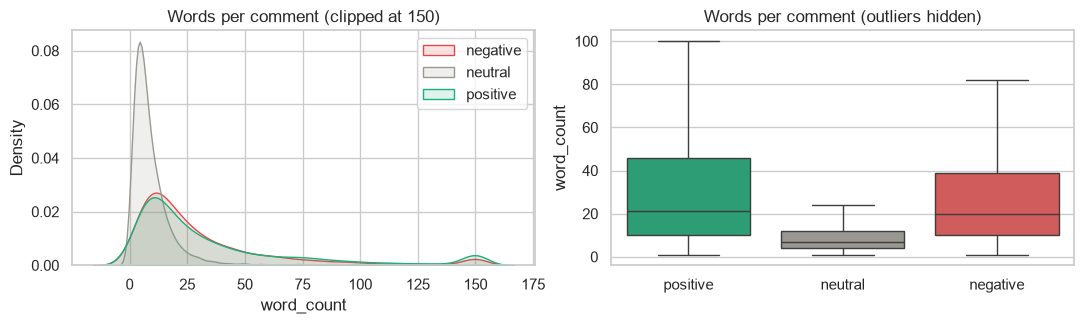

In [5]:
df["word_count"] = df["clean_comment"].str.split().str.len()
df["char_count"] = df["clean_comment"].str.len()
print(df.groupby("label")[["word_count", "char_count"]].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for lab, color in PALETTE.items():
    sns.kdeplot(df.loc[df.label == lab, "word_count"].clip(upper=150), ax=axes[0], color=color, label=lab, fill=True, alpha=.15)
axes[0].set_title("Words per comment (clipped at 150)"); axes[0].legend()
sns.boxplot(data=df, x="label", y="word_count", order=["positive", "neutral", "negative"], palette=PALETTE, ax=axes[1], showfliers=False)
axes[1].set_title("Words per comment (outliers hidden)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig("../reports/eda_word_count.png", dpi=110); plt.show()
EDA["median_words"] = df.groupby("label")["word_count"].median().to_dict()
EDA["comments_over_100_words_pct"] = round(float((df.word_count > 100).mean() * 100), 1)

Most comments are short, with long right tails. **Neutral** comments are the shortest; opinions (positive or negative) take more words.
This is why the course keeps comment length in mind but doesn't use it as a feature.

## 4 · Stop words, punctuation and non-English characters

In [6]:
STOP = set(stopwords.words("english"))
tokens = df["clean_comment"].str.lower().str.split()
df["stopword_count"] = tokens.apply(lambda ws: sum(w in STOP for w in ws))
print("stop-word share of all words: %.1f%%" % (df.stopword_count.sum() / df.word_count.sum() * 100))

top_stop = Counter(w for ws in tokens for w in ws if w in STOP).most_common(15)
print("most common stop words:", top_stop)

NEGATIONS = ["not", "no", "but", "however", "yet", "nor", "never"]
neg_counts = {w: int(tokens.apply(lambda ws: w in ws).sum()) for w in NEGATIONS}
print("comments containing negation words:", neg_counts)

odd = df["clean_comment"].str.contains(r"[^A-Za-z0-9\s!?.,']")
print(f"comments with non-English / special characters: {odd.sum()} ({odd.mean():.1%})")
df.loc[odd, "clean_comment"].head(5)

stop-word share of all words: 33.2%
most common stop words: [('the', 57669), ('and', 28950), ('that', 15372), ('this', 13463), ('for', 12976), ('you', 11723), ('are', 10566), ('not', 8691), ('they', 8654), ('have', 8380), ('with', 7845), ('but', 7264), ('will', 6905), ('was', 6371), ('what', 5270)]
comments containing negation words: {'not': 5657, 'no': 0, 'but': 5118, 'however': 312, 'yet': 419, 'nor': 110, 'never': 966}
comments with non-English / special characters: 2246 (6.1%)


6      was teens when discovered zen meditation was then undiagnosed bpd being homeschooled ...
44     response your question about how amitabha created the pure land this quote from the a...
49    according this nbc chicago article walsh holds ladies week 169189026 html here what th...
62                             aeee mere watan kaee logoo … zaraa aankh mein bharr loo paani … 
66    اللعنة عليك bismillah rasool wasallam barigatul maudolul muhammad sallolulu اللعنة علي...
Name: clean_comment, dtype: str

The dataset was **already partly cleaned** by its author: apostrophes were stripped ("don", "won") and two-letter words seem to be gone (`no` appears in 0 comments).
About 6% of comments still contain non-English script (Hindi, Arabic, emoji). Our cleaning step removes those characters.

**Why keep the negation words?** The standard NLTK list removes `not`, `no` and `but`. Then *"this is **not** good"* becomes *"good"* and the label flips.
The course removes stop words **except** a small keep-list (`not, but, however, no, yet`; we also keep `nor, never`).

## 5 · Most frequent bigrams and trigrams

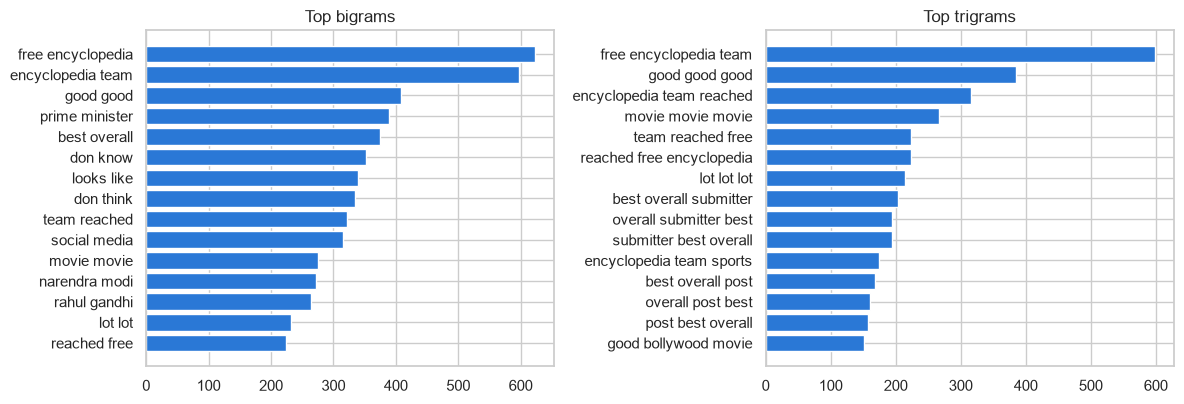

In [7]:
def top_ngrams(texts, n, k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=20000)
    counts = vec.fit_transform(texts).sum(axis=0).A1
    return sorted(zip(vec.get_feature_names_out(), counts), key=lambda x: -x[1])[:k]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, n in zip(axes, (2, 3)):
    words, counts = zip(*top_ngrams(df["clean_comment"], n))
    ax.barh(words[::-1], counts[::-1], color="#2a78d6")
    ax.set_title(f"Top {'bi' if n == 2 else 'tri'}grams")
plt.tight_layout(); plt.savefig("../reports/eda_ngrams.png", dpi=110); plt.show()
EDA["top_bigrams"] = [w for w, _ in top_ngrams(df["clean_comment"], 2, 10)]

Three things stand out:
* **Template or bot text**: "free encyclopedia team reached …" and "best overall submitter …" repeat hundreds of times. They are boilerplate, not opinions.
* **Repetition spam**: "good good good", "movie movie movie", "lot lot lot".
* **Politics**: "prime minister", "narendra modi", "rahul gandhi", "political party", "right wing".

The training data comes from **(mostly Indian political) Reddit threads**, while the extension will read **YouTube comments about all kinds of videos**.
That mismatch between training data and live data (a **domain shift**) is the project's biggest weakness. It's a good point to raise in interviews.

## 6 · The cleaning function (identical to `src/common.py`)

In [8]:
KEEP_WORDS = {"not", "no", "but", "however", "yet", "nor", "never"}
STOP_WORDS = set(stopwords.words("english")) - KEEP_WORDS
lemmatizer = WordNetLemmatizer()

def preprocess_comment(comment: str) -> str:
    text = str(comment).lower().strip()
    text = re.sub(r"\n", " ", text)                  # newlines → spaces
    text = re.sub(r"[^a-z0-9\s!?.,]", "", text)      # keep letters, digits and basic punctuation
    words = [w for w in text.split() if w not in STOP_WORDS]
    return " ".join(lemmatizer.lemmatize(w) for w in words)

examples = ["This video is NOT good at all!!\nWaste of time 😡",
            "The ministers were running the campaigns better than expected",
            "however, I still think yet another tutorial won't help"]
pd.DataFrame({"before": examples, "after": [preprocess_comment(e) for e in examples]})

,before,after
0,This video is NOT good at all!!\nWaste of time 😡,video not good all!! waste time
1,The ministers were running the campaigns better than expected,minister running campaign better expected
2,"however, I still think yet another tutorial won't help","however, still think yet another tutorial wont help"


In [9]:
import sys; sys.path.insert(0, "..")
from src.common import preprocess_comment as project_version
assert all(preprocess_comment(e) == project_version(e) for e in examples), "notebook and src/common.py disagree!"
print("notebook function == src/common.py ✔  (training and serving clean text identically)")

df["processed"] = df["clean_comment"].apply(preprocess_comment)
empty = (df["processed"].str.strip() == "")
print("comments that became empty after cleaning:", empty.sum())
df = df[~empty].reset_index(drop=True)
df[["clean_comment", "processed", "label"]].sample(6, random_state=1)

notebook function == src/common.py ✔  (training and serving clean text identically)


comments that became empty after cleaning: 131


,clean_comment,processed,label
25465,lets not count the chickens before they hatch also can someone tell how exactly the vo...,let not count chicken hatch also someone tell exactly vote counted evm evms consituenc...,positive
23468,anyone know there hotel nearby ish american school singapore,anyone know hotel nearby ish american school singapore,neutral
18268,wish the fucking incompetent media would hold debates this issue like they muslim mull...,wish fucking incompetent medium would hold debate issue like muslim mullah hindu pries...,positive
24712,thought state was free all this shit then wild shabarimala appeared,thought state free shit wild shabarimala appeared,positive
19099,and then what make statue your veer savarkar there,make statue veer savarkar,neutral
25398,mujhe dala klash gye sare flush atal bihari,mujhe dala klash gye sare flush atal bihari,neutral


## 7 · Word clouds and top words per class

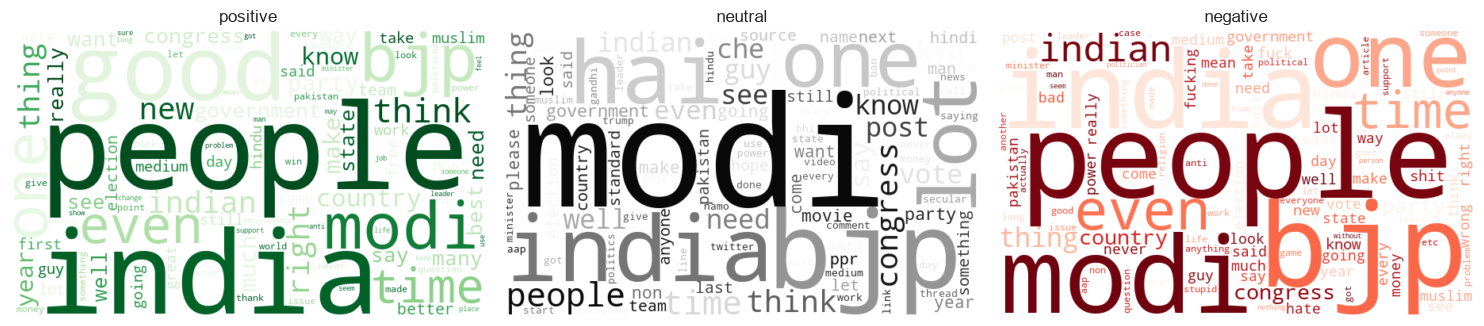

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cmaps = {"positive": "Greens", "neutral": "Greys", "negative": "Reds"}
for ax, lab in zip(axes, ["positive", "neutral", "negative"]):
    text = " ".join(df.loc[df.label == lab, "processed"])
    wc = WordCloud(width=600, height=360, background_color="white", colormap=cmaps[lab],
                   collocations=False, max_words=100, random_state=0).generate(text)
    ax.imshow(wc, interpolation="bilinear"); ax.axis("off"); ax.set_title(lab)
plt.tight_layout(); plt.savefig("../reports/eda_wordclouds.png", dpi=110); plt.show()

In [11]:
top = {}
for lab in ["positive", "neutral", "negative"]:
    c = Counter(w for text in df.loc[df.label == lab, "processed"] for w in text.split())
    top[lab] = [w for w, _ in c.most_common(12)]
pd.DataFrame(top)

,positive,neutral,negative
0,not,not,not
1,but,modi,but
2,people,bjp,people
3,india,like,bjp
4,like,india,like
5,good,hai,india
6,bjp,but,modi
7,modi,one,one
8,one,lot,get
9,would,people,even


The top words overlap heavily between classes (`modi`, `india`, `bjp`, …), so single words alone separate the classes poorly.
`not` is the most frequent word in **every** class once we keep it, so on its own it doesn't tell the classes apart. In pairs such as "not good" it does.
That's why **n-grams** get their own experiment in notebook 2.

Look at the random sample in step 6: some labels look wrong (an angry comment labelled *positive*). The labels were produced automatically, so the dataset has **label noise**.
That caps achievable accuracy, whatever model we pick.

## 8 · Save for notebook 2

In [12]:
out = df[["processed", "category"]].rename(columns={"processed": "clean_comment"})
out.to_csv("reddit_preprocessing.csv", index=False)
EDA["rows_after_cleaning"] = int(len(out))
json.dump(EDA, open("../reports/eda_summary.json", "w"), indent=1)
print(out.shape); print(json.dumps(EDA, indent=1))

(36662, 2)
{
 "rows": 36793,
 "class_percent": {
  "positive": 42.9,
  "neutral": 34.7,
  "negative": 22.4
 },
 "median_words": {
  "negative": 20.0,
  "neutral": 7.0,
  "positive": 21.0
 },
 "comments_over_100_words_pct": 5.1,
 "top_bigrams": [
  "free encyclopedia",
  "encyclopedia team",
  "good good",
  "prime minister",
  "best overall",
  "don know",
  "looks like",
  "don think",
  "team reached",
  "social media"
 ],
 "rows_after_cleaning": 36662
}
